קרא את הנתונים 

In [1]:
import pandas as pd

# read  the data from local file  
data = pd.read_csv('cancer_data.csv',header=None)
data

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_23364\548105532.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


,0,1,2,3,4,5,6,7,8,9
0,1397.000000,469,489.800000,61898,260131,11.2,39.3,36.9,41.7,164.9
1,173.000000,70,411.600000,48127,43269,18.6,33.0,32.2,33.7,161.3
2,102.000000,50,349.700000,49348,21026,14.6,45.0,44.0,45.8,174.7
3,427.000000,202,430.400000,44243,75882,17.1,42.8,42.2,43.4,194.8
4,57.000000,26,350.100000,49955,10321,12.5,48.3,47.8,48.9,144.4
...,...,...,...,...,...,...,...,...,...,...
3042,1962.667684,15,453.549422,46961,6343,12.4,44.2,41.1,48.8,149.6
3043,1962.667684,43,453.549422,48609,37118,18.8,30.4,29.3,31.4,150.1
3044,1962.667684,46,453.549422,51144,34536,15.0,30.9,30.5,31.2,153.9
3045,1962.667684,52,453.549422,50745,25609,13.3,39.0,36.9,40.5,175.0


X והכנס למטריצה 

y ווקטור 

In [2]:

X = data.drop(columns=data.columns[-1])
y = data[data.columns[-1]].values

X = X.astype('float64')
y = y.astype('float64')

print(X)
print('-' * 50)
print(y)


                0      1           2        3         4     5     6     7  \
0     1397.000000  469.0  489.800000  61898.0  260131.0  11.2  39.3  36.9   
1      173.000000   70.0  411.600000  48127.0   43269.0  18.6  33.0  32.2   
2      102.000000   50.0  349.700000  49348.0   21026.0  14.6  45.0  44.0   
3      427.000000  202.0  430.400000  44243.0   75882.0  17.1  42.8  42.2   
4       57.000000   26.0  350.100000  49955.0   10321.0  12.5  48.3  47.8   
...           ...    ...         ...      ...       ...   ...   ...   ...   
3042  1962.667684   15.0  453.549422  46961.0    6343.0  12.4  44.2  41.1   
3043  1962.667684   43.0  453.549422  48609.0   37118.0  18.8  30.4  29.3   
3044  1962.667684   46.0  453.549422  51144.0   34536.0  15.0  30.9  30.5   
3045  1962.667684   52.0  453.549422  50745.0   25609.0  13.3  39.0  36.9   
3046  1962.667684   48.0  453.549422  41193.0   37030.0  13.9  26.2  25.5   

         8  
0     41.7  
1     33.7  
2     45.8  
3     43.4  
4     48.9

א)	נרמל את הנתונים (בצע בדיקה שאחרי הנרמול אכן הממוצע 0 וסטית התקן 1).

In [3]:

X_normalized = (X - X.mean(axis=0)) / X.std(axis=0)
mean_after_normalized = X_normalized.mean()
std_after_normalized = X_normalized.std()
#print(mean_after_normalized)
print('-' * 50)
#print(std_after_normalized)

#X_normalized 
print(X - X.mean())



--------------------------------------------------
                0           1          2             3              4  \
0      790.661456  283.034132  41.531414  14834.718083  157493.629472   
1     -433.338544 -115.965868 -36.668586   1063.718083  -59368.370528   
2     -504.338544 -135.965868 -98.568586   2284.718083  -81611.370528   
3     -179.338544   16.034132 -17.868586  -2820.281917  -26755.370528   
4     -549.338544 -159.965868 -98.168586   2891.718083  -92316.370528   
...           ...         ...        ...           ...            ...   
3042  1356.329140 -170.965868   5.280836   -102.281917  -96294.370528   
3043  1356.329140 -142.965868   5.280836   1545.718083  -65519.370528   
3044  1356.329140 -139.965868   5.280836   4080.718083  -68101.370528   
3045  1356.329140 -133.965868   5.280836   3681.718083  -77028.370528   
3046  1356.329140 -137.965868   5.280836  -5870.281917  -65607.370528   

             5          6          7          8  
0    -5.678175  -5.972

 X ב ) הוסף עמודה של אחדים למטריצה 

In [4]:
import numpy as np
X_normalized_with_oneColum = X_normalized.copy()
X_normalized_with_oneColum.insert(0, 'bise', 1)
print(X_normalized.shape)

#change the column name 
new_column_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
X_normalized_with_oneColum.columns= new_column_names
X_normalized_with_oneColum


(3047, 9)


,0,1,2,3,4,5,6,7,8,9
0,1,0.558236,0.561426,0.761196,1.232110,0.478618,-0.885957,-0.131827,-0.511044,-0.084137
1,1,-0.305953,-0.230030,-0.672069,0.088348,-0.180418,0.268654,-0.270886,-1.410391,-1.595610
2,1,-0.356082,-0.269702,-1.806585,0.189759,-0.248014,-0.355460,-0.006011,0.847543,0.690493
3,1,-0.126620,0.031805,-0.327499,-0.234241,-0.081309,0.034611,-0.054572,0.503113,0.237051
4,1,-0.387853,-0.317308,-1.799253,0.240174,-0.280546,-0.683120,0.066829,1.574674,1.276189
...,...,...,...,...,...,...,...,...,...,...
3042,1,0.957619,-0.339128,0.096788,-0.008495,-0.292635,-0.698723,-0.023669,0.292627,1.257296
3043,1,0.957619,-0.283587,0.096788,0.128381,-0.199111,0.299859,-0.328275,-1.965307,-2.030159
3044,1,0.957619,-0.277636,0.096788,0.338928,-0.206958,-0.293049,-0.317239,-1.735686,-2.067945
3045,1,0.957619,-0.265734,0.096788,0.305788,-0.234087,-0.558297,-0.138448,-0.511044,-0.310858


	Θ רשום פונקציה שמקבלת    
    ומחזירה את  X   ווקטור  
    h_Θ (x)
    

In [5]:
def predict(theta , X):
     return np.dot(X,theta)

X ו-y מטריצות Θ רשום פונקציה שמקבלת וקטור

J(Θ)  ומחזירה את הערך של  


In [6]:
def MSE_cost(theta, X, y):
    m = len(y)
    predictions = predict(theta, X)
    sqe_error = ((predictions - y)**2)
    return (1/(2*m)) * np.sum(sqe_error)


 Θ  רשום פונקציה שמקבלת וקטור 
 
X ו-y   ומטריצות

∇J(Θ) ומחזירה את הערך של  



In [7]:
def gradient(theta , X , y):
    m = len(y)
    predictions = predict(theta, X)
    return (1/(m)) * np.dot(X.T,(predictions - y))

In [8]:
# check both of MSE_cost and gradient 
theta_initial = np.zeros(X_normalized_with_oneColum.shape[1])
print(theta_initial)
cost_initial = MSE_cost(theta_initial ,X_normalized_with_oneColum, y)
gradient_initial = gradient(theta_initial,X_normalized_with_oneColum, y)

(cost_initial, gradient_initial)



[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


(16345.370518542828,
 array([-1.78664063e+02,  3.98191211e+00,  2.51665657e+00, -1.24683155e+01,
         1.18908083e+01,  3.33111627e+00, -1.19122824e+01, -1.21375157e-01,
         6.08375070e-01, -3.34251185e-01]))

	 (למשל 1,0.1, 0.01, 0.001) α  עם כמה ערכים של Gradient Descent הרץ את אלגוריתם 
      כפונקציה של צעדי זמן J(Θ) וצייר את הגרף שמראה את ירידת הערך של  

In [9]:
def SGD_gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost = []
    
    for i in range(iterations):
        theta = theta - alpha * gradient(theta, X, y)
        cost.append(MSE_cost(theta, X, y))
    return theta, cost


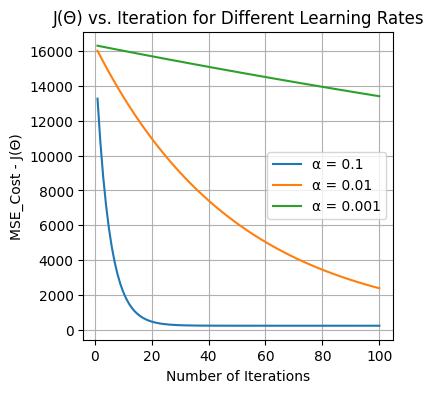

In [10]:
import matplotlib.pyplot as plt

# Parameters for gradient descent
iterations = 100
alphas = [0.1, 0.01, 0.001]

# Run Gradient Descent with different alphas
plt.figure(figsize=(4, 4))

for alpha in alphas:
    theta = np.zeros(X_normalized_with_oneColum.shape[1])
    _, cost = SGD_gradient_descent(X_normalized_with_oneColum, y, theta, alpha, iterations)
    
    plt.plot(range(1, iterations + 1), cost , label=f'α = {alpha}')

plt.xlabel('Number of Iterations')
plt.ylabel('MSE_Cost - J(Θ)')
plt.title('J(Θ) vs. Iteration for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()


 השווה לסעיף הקודם. מה מסקנותיך מהריצה mini-batch	הרץ את אותו הקוד עם 
 

In [11]:
def mini_batch_gradient_descent(X, y, theta, alpha, iterations, batch_size):
    m = len(y)
    X_np = X.to_numpy() if isinstance(X, pd.DataFrame) else X
    y_np = y.to_numpy() if isinstance(y, pd.Series) else y
    MSE = [] 
    n_batches = int(m / batch_size)
    
    for i in range(iterations):
        indices = np.random.permutation(m)
        X_shuffled = X_np[indices]
        y_shuffled = y_np[indices]
        for batch in range(n_batches):
            start_index = batch * batch_size
            end_index = start_index + batch_size
            X_batch = X_shuffled[start_index:end_index]
            y_batch = y_shuffled[start_index:end_index]
            
            theta = theta - alpha * gradient(theta, X_batch, y_batch)
        
        cost = MSE_cost(theta, X, y)
        MSE.append(cost)
    
    
    return theta, MSE

   

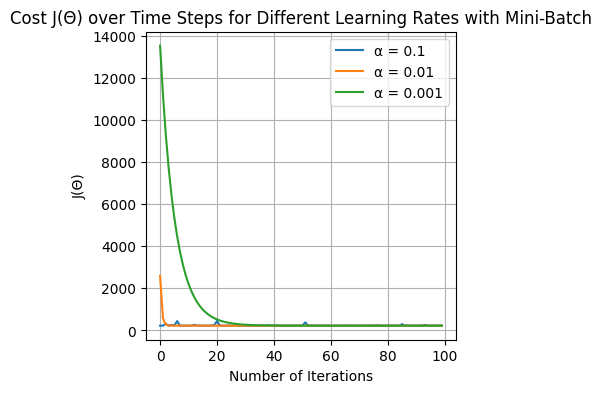

In [12]:

batch_size = 32 # Example batch size
iterations_mini_batch = 100 # Using fewer iterations due to more updates per iteration
alphas = [0.1, 0.01, 0.001]
# Run Mini-Batch Gradient Descent for each learning rate and plot the cost history
plt.figure(figsize=(4, 4))

for alpha in alphas:
    theta = np.zeros(X_normalized_with_oneColum.shape[1])
    _, cost_history_mini = mini_batch_gradient_descent(X_normalized_with_oneColum, y, theta, alpha, iterations_mini_batch, batch_size)
    plt.plot(cost_history_mini, label=f'α = {alpha}')
   

plt.xlabel('Number of Iterations')
plt.ylabel('J(Θ)')
plt.title('Cost J(Θ) over Time Steps for Different Learning Rates with Mini-Batch')
plt.legend()
plt.grid(True)
plt.show()

Conclusions:
The choice of α affects the value of J(Θ) in different Iterations.
Mini-batch processing is typically more computationally efficient  especially with large datasets, as it does not require the entire dataset to be loaded into memory.
The rapid convergence .

In [13]:
from scipy.linalg import svd

def reduce_dimensions_svd(X, n_components=3):
  
    U, S, VT = svd(X, full_matrices=False)
    X_reduced = np.dot(U[:, :n_components], np.diag(S[:n_components]))
    return X_reduced

# t0 check the reduce_dimensions_svd
X_reduced = reduce_dimensions_svd(X_normalized, n_components=3)
print(X_reduced)

print('-' * 50)
# add one columns 
X_reduced_with_ones = np.c_[np.ones((X_reduced.shape[0], 1)), X_reduced]
print(X_reduced_with_ones)

[[-1.41236012 -0.49946802 -1.01846689]
 [-0.21409018  1.93588343 -1.0481067 ]
 [ 0.76140447 -1.04081406 -0.13999493]
 ...
 [-1.16440154  1.94918315 -1.47865826]
 [-0.5575897   0.08949798 -0.66670836]
 [-1.35134354  3.13013273 -1.60705186]]
--------------------------------------------------
[[ 1.         -1.41236012 -0.49946802 -1.01846689]
 [ 1.         -0.21409018  1.93588343 -1.0481067 ]
 [ 1.          0.76140447 -1.04081406 -0.13999493]
 ...
 [ 1.         -1.16440154  1.94918315 -1.47865826]
 [ 1.         -0.5575897   0.08949798 -0.66670836]
 [ 1.         -1.35134354  3.13013273 -1.60705186]]


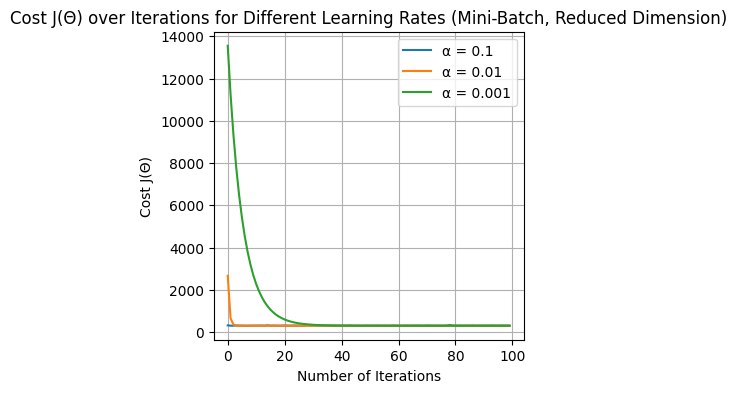

In [14]:

iterations = 100
plt.figure(figsize=(4, 4))

for alpha in alphas:
    theta_reduced = np.zeros(X_reduced_with_ones.shape[1])
    _, cost_history_mini_with_reduced = mini_batch_gradient_descent(X_reduced_with_ones, y, theta_reduced, alpha, iterations, batch_size)
    
    plt.plot(cost_history_mini_with_reduced, label=f'α = {alpha}')

plt.xlabel('Number of Iterations')
plt.ylabel('Cost J(Θ)')
plt.title('Cost J(Θ) over Iterations for Different Learning Rates (Mini-Batch, Reduced Dimension)')
plt.legend()
plt.grid(True)
plt.show()

Conclusions: 
The result is almost similar to Mini-Batch, but with a slight difference when alpha is 0.1, and that's mean that the first 3  feater contain the data more important.

Compare the difference in the runtime when use Gradient Descent with full data "without dimension reduction"  
and dimension reduction by SVD

In [15]:
import time

iterations = 100
alphas = [0.1, 0.01, 0.001]

# Run Gradient Descent to compar the run time 

runtimes_full_data = []
runtimes_reduced_data = []

# Before dimension reduction
for alpha in alphas:
    theta = np.zeros(X_normalized_with_oneColum.shape[1])
    start_time = time.time()
    _, cost_history_with_all = SGD_gradient_descent(X_normalized_with_oneColum, y, theta, alpha, iterations)
    end_time = time.time()
    runtimes_full_data.append(end_time - start_time)
   
print("Full data run time:", end_time - start_time, "seconds")

# After dimension reduction
for alpha in alphas:
    theta_reduced = np.zeros(X_reduced_with_ones.shape[1])
    start_time = time.time()
    _, cost_history_with_reduced = SGD_gradient_descent(X_reduced_with_ones, y, theta_reduced, alpha, iterations)
    end_time = time.time()
    runtimes_reduced_data.append(end_time - start_time)
    
    
print("Reduced data run time:", end_time - start_time, "seconds")




Full data run time: 0.26196885108947754 seconds
Reduced data run time: 0.09740233421325684 seconds


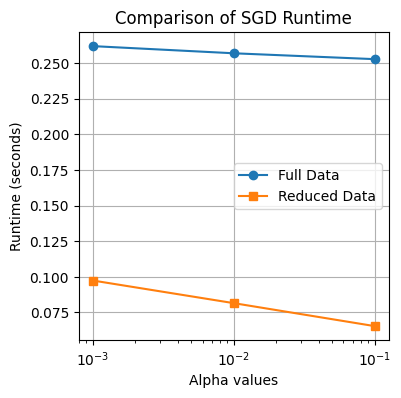

In [16]:
plt.figure(figsize=(4, 4))
plt.plot(alphas, runtimes_full_data, label='Full Data', marker='o')
plt.plot(alphas, runtimes_reduced_data, label='Reduced Data', marker='s')

# Adding plot details
plt.title('Comparison of SGD Runtime')
plt.xlabel('Alpha values')
plt.ylabel('Runtime (seconds)')
plt.xscale('log')  # Since alpha values vary logarithmically
plt.legend()
plt.grid(True)

plt.show()

Compare the difference in the runtime when use mini_batch_gradient_descent with full data "without dimension reduction"  
and dimension reduction by SVD

In [17]:
iterations = 100
batch_size = 32 
alphas = [0.1, 0.01, 0.001]

# Run Gradient Descent to compar the run time 

runtimes_full_data = []
runtimes_reduced_data = []

# Before dimension reduction
for alpha in alphas:
    theta = np.zeros(X_normalized_with_oneColum.shape[1])
    start_time = time.time()
    _, cost_history_with_all = mini_batch_gradient_descent(X_normalized_with_oneColum, y, theta, alpha, iterations, batch_size)
    end_time = time.time()
    runtimes_full_data.append(end_time - start_time)
   
print("Full data run time:", end_time - start_time, "seconds")

# After dimension reduction
for alpha in alphas:
    theta_reduced = np.zeros(X_reduced_with_ones.shape[1])
    start_time = time.time()
    _, cost_history_with_reduced = mini_batch_gradient_descent(X_reduced_with_ones, y, theta_reduced, alpha, iterations, batch_size)
    end_time = time.time()
    runtimes_reduced_data.append(end_time - start_time)
    
print("Reduced data run time:", end_time - start_time, "seconds")

Full data run time: 0.7119877338409424 seconds


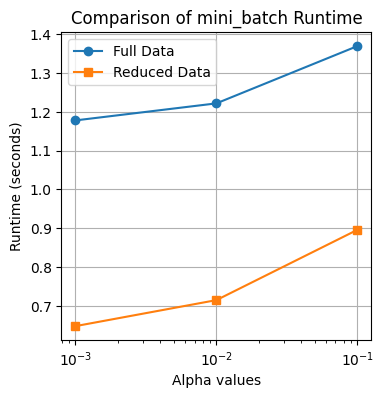

In [ ]:
plt.figure(figsize=(4, 4))
plt.plot(alphas, runtimes_full_data, label='Full Data', marker='o')
plt.plot(alphas, runtimes_reduced_data, label='Reduced Data', marker='s')

# Adding plot details
plt.title('Comparison of mini_batch Runtime')
plt.xlabel('Alpha values')
plt.ylabel('Runtime (seconds)')
plt.xscale('log')  # Since alpha values vary logarithmically
plt.legend()
plt.grid(True)

plt.show()